### Traning transformer model on low resourced ssl (3-10 instance per class)

In [174]:
import os
import json
import shutil
import pickle
import numpy as np
import matplotlib.pyplot as plt
import joblib
import seaborn as sns

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking, BatchNormalization, Bidirectional, MaxPooling1D, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from keras.utils import plot_model
from collections import Counter



In [175]:
# check if the gpu support available
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [176]:
data_directory = '../all_outputs/output_ssl_small/'

# list all the files in directories and sub directories in in data_direcotiry and store them list_list list
file_names = []

for root, _, files in os.walk(data_directory):  # Walk through all directories and subdirectories
        for filename in files:
            file_names.append(os.path.join(root, filename))

print(len(file_names))            

960


In [177]:
all_data = []


# Define indices for points of interest
pose_indices = [0, 15, 16, 17, 18, 19, 20]
hand_indices = [0, 4, 7, 8, 11, 12, 15, 16, 19, 20]

# pose_indices = [0, 11, 12, 13, 14, 15, 16, 23, 24]
# hand_indices = [0, 1, 3, 4, 6, 8, 10, 12, 14, 16, 18, 20]

In [178]:

def load_landmarks(filenames, num_frames, glossIndex = 4):
    
    
    # Prepare storage for data and labels
    video_data = []
    labels = []
    
    for file in filenames:
     
        print(file)
        gloss = file.split('/')[glossIndex]
        print(gloss)


        with open(file, 'rb') as f:
                landmarks = pickle.load(f)
                    
                # Prepare frame storage for each video with fixed number of frames
                frames = []

                # Get frame sampling step (skip frames if necessary)
                total_frames = len(landmarks)
                step = max(1, total_frames // num_frames)
                    
                # Process frames
                for i in range(num_frames):
                    frame_index = i * step if total_frames >= num_frames else i
                    
                    if frame_index < total_frames:
                        frame = landmarks[frame_index]
                    else:
                        frame = None
                        
                    # Extract and flatten required points
                    pose_points = frame['pose_landmarks'] if frame and frame['pose_landmarks'] else [None] * 33
                    left_hand_points = frame['left_hand_landmarks'] if frame and frame['left_hand_landmarks'] else [None] * 21
                    right_hand_points = frame['right_hand_landmarks'] if frame and frame['right_hand_landmarks'] else [None] * 21
                        
                    # Collect only specified indices and flatten them
                    extracted_points = []

                    # Collect pose points first
                    for idx in pose_indices:
                        point = pose_points[idx] if pose_points[idx] is not None else {'x': 0, 'y': 0}
                        extracted_points.extend([point['x'], point['y']])
                        
                    # print(left_hand_points)
                    for idx in hand_indices:
                        point = left_hand_points[idx] if left_hand_points[idx] is not None else {'x': 0, 'y': 0}
                        extracted_points.extend([point['x'], point['y']])

                    # Collect right hand points
                    for idx in hand_indices:
                        point = right_hand_points[idx] if right_hand_points[idx] is not None else {'x': 0, 'y': 0}
                        extracted_points.extend([point['x'], point['y']])
                        
                    frames.append(extracted_points)
                    
                # Add the processed video frames to the main array
                video_data.append(frames)
                labels.append(gloss)
                

    # Convert to numpy arrays
    video_data = np.array(video_data)
    labels = np.array(labels)
    
    return video_data, labels

# Example usage
num_frames = 30  # Desired fixed number of frames per video

video_data, labels = load_landmarks(file_names, num_frames, 3)

# `video_data` has shape (number of videos, num_frames, number of points*2) where points*2 is the flattened landmark count
# `labels` contains the labels for each video


../all_outputs/output_ssl_small/To_You/2-3-w00120221110095636.mp4_1.pkl
To_You
../all_outputs/output_ssl_small/To_You/1-5-w00120221103105424.mp4_1.pkl
To_You
../all_outputs/output_ssl_small/To_You/3-2-w00120221216115531.mp4_1.pkl
To_You
../all_outputs/output_ssl_small/To_You/4-5-w00120221216115618.mp4_1.pkl
To_You
../all_outputs/output_ssl_small/To_You/1-2-w00120221103105346.mp4_1.pkl
To_You
../all_outputs/output_ssl_small/To_You/2-2-w00120221110095626.mp4_1.pkl
To_You
../all_outputs/output_ssl_small/To_You/2-4-w00120221110095645.mp4_1.pkl
To_You
../all_outputs/output_ssl_small/To_You/4-3-w00120221216115558.mp4_1.pkl
To_You
../all_outputs/output_ssl_small/To_You/4-1-w00120221216115524_1.pkl
To_You
../all_outputs/output_ssl_small/To_You/4-4-w00120221216115608.mp4_1.pkl
To_You
../all_outputs/output_ssl_small/To_You/3-1-w00120221216115520.mp4_1.pkl
To_You
../all_outputs/output_ssl_small/To_You/3-3-w00120221216115540.mp4_1.pkl
To_You
../all_outputs/output_ssl_small/To_You/2-5-w001202211100

In [179]:
NUM_CLASSES = len(set(labels))
NUM_CLASSES

48

In [180]:

# Set the number of instances per class in the training set
INSTANCES_PER_CLASS = 4  # Change this as needed (e.g., 2, 3, 4, etc.)
CUSTOM_NUM_CLASSES = NUM_CLASSES  # Assuming NUM_CLASSES is defined elsewhere

# Count the occurrences of each class
class_counts = Counter(labels)

# Sort classes by their counts in descending order and select the top NUM_CLASSES classes
top_classes = [cls for cls, count in class_counts.most_common(CUSTOM_NUM_CLASSES)]

# Filter the dataset to keep only the samples belonging to the top classes
filtered_indices = [i for i, label in enumerate(labels) if label in top_classes]
video_data_filtered = video_data[filtered_indices]
labels_filtered = labels[filtered_indices]

# Encode labels after filtering
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels_filtered)

# Custom split to ensure fixed instances per class in training set
train_indices = []
val_test_indices = []

for cls in range(len(top_classes)):
    # Get indices of samples for this class
    cls_indices = np.where(labels_encoded == cls)[0]
    np.random.shuffle(cls_indices)  # Randomize the order
    # Ensure there are enough samples for the class
    if len(cls_indices) < INSTANCES_PER_CLASS:
        raise ValueError(f"Class {cls} has only {len(cls_indices)} instances, but {INSTANCES_PER_CLASS} are required.")
    # Take fixed number of instances for training
    train_indices.extend(cls_indices[:INSTANCES_PER_CLASS])
    # Remaining instances go to validation/test
    val_test_indices.extend(cls_indices[INSTANCES_PER_CLASS:])

# Convert to numpy arrays
X_train = video_data_filtered[train_indices]
y_train = labels_encoded[train_indices]
X_temp = video_data_filtered[val_test_indices]
y_temp = labels_encoded[val_test_indices]

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=len(top_classes))
y_temp = to_categorical(y_temp, num_classes=len(top_classes))

# Split remaining data into validation and test sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, shuffle=True, random_state=42)

# Print train, val, test shapes
print("Train shapes:", X_train.shape, y_train.shape)
print("Validation shapes:", X_val.shape, y_val.shape)
print("Test shapes:", X_test.shape, y_test.shape)

# Verify and print number of instances per class in training set
y_train_indices = np.argmax(y_train, axis=1)
class_counts_train = Counter(y_train_indices)
print("Number of instances per class in training set:")
for class_idx, count in sorted(class_counts_train.items()):
    print(f"Class {class_idx}: {count} instances")
print(f"Total unique classes: {len(class_counts_train)}")
print(f"Average instances per class: {sum(class_counts_train.values()) / len(class_counts_train):.2f}")

NUM_CLASSES = CUSTOM_NUM_CLASSES

Train shapes: (192, 30, 54) (192, 48)
Validation shapes: (384, 30, 54) (384, 48)
Test shapes: (384, 30, 54) (384, 48)
Number of instances per class in training set:
Class 0: 4 instances
Class 1: 4 instances
Class 2: 4 instances
Class 3: 4 instances
Class 4: 4 instances
Class 5: 4 instances
Class 6: 4 instances
Class 7: 4 instances
Class 8: 4 instances
Class 9: 4 instances
Class 10: 4 instances
Class 11: 4 instances
Class 12: 4 instances
Class 13: 4 instances
Class 14: 4 instances
Class 15: 4 instances
Class 16: 4 instances
Class 17: 4 instances
Class 18: 4 instances
Class 19: 4 instances
Class 20: 4 instances
Class 21: 4 instances
Class 22: 4 instances
Class 23: 4 instances
Class 24: 4 instances
Class 25: 4 instances
Class 26: 4 instances
Class 27: 4 instances
Class 28: 4 instances
Class 29: 4 instances
Class 30: 4 instances
Class 31: 4 instances
Class 32: 4 instances
Class 33: 4 instances
Class 34: 4 instances
Class 35: 4 instances
Class 36: 4 instances
Class 37: 4 instances
Class 38:

In [181]:
def augment_data(x):
    # Add random noise to the input
    noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=0.01)
    return x + noise

# Apply augmentation during training
X_train_augmented = augment_data(X_train)
# X_train_augmented = X_train

print(X_train_augmented.shape, y_train.shape)

(192, 30, 54) (192, 48)


In [182]:
# input_shape=(num_frames, len(pose_indices) * 2 + len(hand_indices) * 2 * 2)

In [183]:
import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers


class PositionEmbedding(layers.Layer):
    def __init__(self, config):
        super(PositionEmbedding, self).__init__()
        self.position_embeddings = self.add_weight(
            name="position_embeddings",
            shape=(config.max_position_embeddings, config.hidden_size),
            initializer="random_normal",
            trainable=True,
        )
    
    def call(self, x):
        seq_length = tf.shape(x)[1]
        positions = tf.range(start=0, limit=seq_length, delta=1)
        position_embeddings = tf.gather(self.position_embeddings, positions)
        return x + position_embeddings


class Transformer(Model):
    def __init__(self, config, n_classes=50, freeze_pretrained=False):
        super(Transformer, self).__init__()
        self.l1 = layers.Dense(config.hidden_size, activation=None, kernel_regularizer=regularizers.l2(0.001))
        self.embedding = PositionEmbedding(config)
        
        # Transformer layers
        self.transformer_layers = [
            layers.MultiHeadAttention(
                num_heads=config.num_attention_heads, 
                key_dim=config.hidden_size // config.num_attention_heads,
                kernel_regularizer=regularizers.l2(0.001)
            )
            for _ in range(config.num_hidden_layers)
        ]
        
        # Layer normalization
        self.layer_norms = [
            layers.LayerNormalization(epsilon=1e-6)
            for _ in range(config.num_hidden_layers)
        ]
        
        # Final classification layer (will be replaced during fine-tuning)
        self.l2 = layers.Dense(n_classes, activation=None, kernel_regularizer=regularizers.l2(0.001))
        self.dropout = layers.Dropout(0.3)
        
        # Optionally freeze pretrained layers
        if freeze_pretrained:
            for layer in [self.l1, self.embedding] + self.transformer_layers + self.layer_norms:
                layer.trainable = False

    def call(self, x, training=False):
        x = self.l1(x)
        x = self.embedding(x)
        
        for i, layer in enumerate(self.transformer_layers):
            x = layer(x, x)  # Self-attention
            x = self.layer_norms[i](x)  # Apply LayerNormalization
        
        x = tf.reduce_max(x, axis=1)  # Global max pooling
        x = self.dropout(x, training=training)
        x = self.l2(x)
        return x
    
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=10,         # Stop if no improvement for 10 epochs
    restore_best_weights=True  # Restore weights from the best epoch
)

In [184]:
# Configuration
num_features = X_train_augmented.shape[2]
print("Num features: ", num_features)
print("Num features: ", X_train_augmented.shape)


class Config:
    input_size = num_features
    hidden_size = 128
    num_hidden_layers = 4
    num_attention_heads = 8
    max_position_embeddings = 30  # Maximum number of frames
    num_classes = NUM_CLASSES  # Number of output classes

config = Config()

# Build the model
model = Transformer(config, n_classes=config.num_classes)

# Print the model summary
model.build(input_shape=(None, config.max_position_embeddings, config.input_size))
model.summary()

Num features:  54
Num features:  (192, 30, 54)
Model: "transformer_22"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_44 (Dense)            multiple                  7040      
                                                                 
 position_embedding_22 (Pos  multiple                  3840      
 itionEmbedding)                                                 
                                                                 
 multi_head_attention_88 (M  multiple                  66048     
 ultiHeadAttention)                                              
                                                                 
 multi_head_attention_89 (M  multiple                  66048     
 ultiHeadAttention)                                              
                                                                 
 multi_head_attention_90 (M  multiple                  66048     
 ulti

In [185]:


# Convert one-hot encoded labels to class indices
y_train_indices = np.argmax(y_train, axis=1)
y_val_indices = np.argmax(y_val, axis=1)
y_test_indices = np.argmax(y_test, axis=1)

# Calculate class weights
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_indices),  # Unique class indices
    y=y_train_indices                     # Class indices for training data
)
class_weights = dict(enumerate(class_weights))  # Convert to dictionary

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True, label_smoothing=0.1),
    metrics=['accuracy']
)

# Train the model with class weights
history = model.fit(
    X_train_augmented, 
    y_train, 
    validation_data=(X_val, y_val), 
    epochs=250, 
    batch_size=32, 
    callbacks=[early_stopping],
    class_weight=class_weights
)

# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

Epoch 1/250
6/6 [==============================] - 7s 94ms/step - loss: 4.9278 - accuracy: 0.0365 - val_loss: 4.3721 - val_accuracy: 0.0208
Epoch 2/250
6/6 [==============================] - 0s 20ms/step - loss: 4.7283 - accuracy: 0.0312 - val_loss: 4.2645 - val_accuracy: 0.0182
Epoch 3/250
6/6 [==============================] - 0s 20ms/step - loss: 4.4992 - accuracy: 0.0208 - val_loss: 4.2066 - val_accuracy: 0.0260
Epoch 4/250
6/6 [==============================] - 0s 20ms/step - loss: 4.4394 - accuracy: 0.0521 - val_loss: 4.1425 - val_accuracy: 0.0677
Epoch 5/250
6/6 [==============================] - 0s 20ms/step - loss: 4.4380 - accuracy: 0.0417 - val_loss: 4.1193 - val_accuracy: 0.1042
Epoch 6/250
6/6 [==============================] - 0s 20ms/step - loss: 4.4539 - accuracy: 0.0260 - val_loss: 4.0800 - val_accuracy: 0.0469
Epoch 7/250
6/6 [==============================] - 0s 19ms/step - loss: 4.2898 - accuracy: 0.0677 - val_loss: 4.0021 - val_accuracy: 0.0781
Epoch 8/250
6/6 [===

In [186]:
# model_path = '../saved_models/book_9/pretrained_model_weights.h5'

In [187]:
# model.save_weights(model_path)

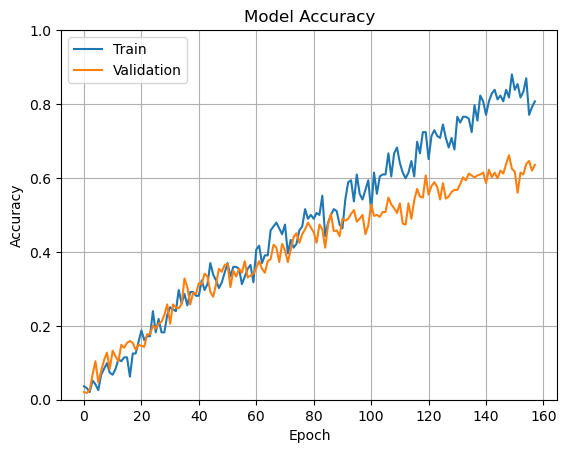

In [188]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.ylim(0, 1)
plt.grid(True)
plt.legend(['Train', 'Validation'], loc='upper left')
save_plt = plt
plt.show()


In [189]:
# Calculate F1 score and other parameters
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)


# Calculate F1 score and other parameters
f1 = f1_score(y_test.argmax(axis=1), y_pred_classes, average='weighted')
precision = precision_score(y_test.argmax(axis=1), y_pred_classes, average='weighted')
recall = recall_score(y_test.argmax(axis=1), y_pred_classes, average='weighted')
accuracy = accuracy_score(y_test.argmax(axis=1), y_pred_classes)

print("F1 Score:", f1)
print("Precision:", precision)
print("Recall:", recall)
print("Accuracy:", accuracy)

12/12 [==============================] - 0s 3ms/step
F1 Score: 0.613099024717724
Precision: 0.6806945579958489
Recall: 0.6276041666666666
Accuracy: 0.6276041666666666


/home/neethamadhu/miniconda3/envs/tf/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


12/12 [==============================] - 0s 3ms/step


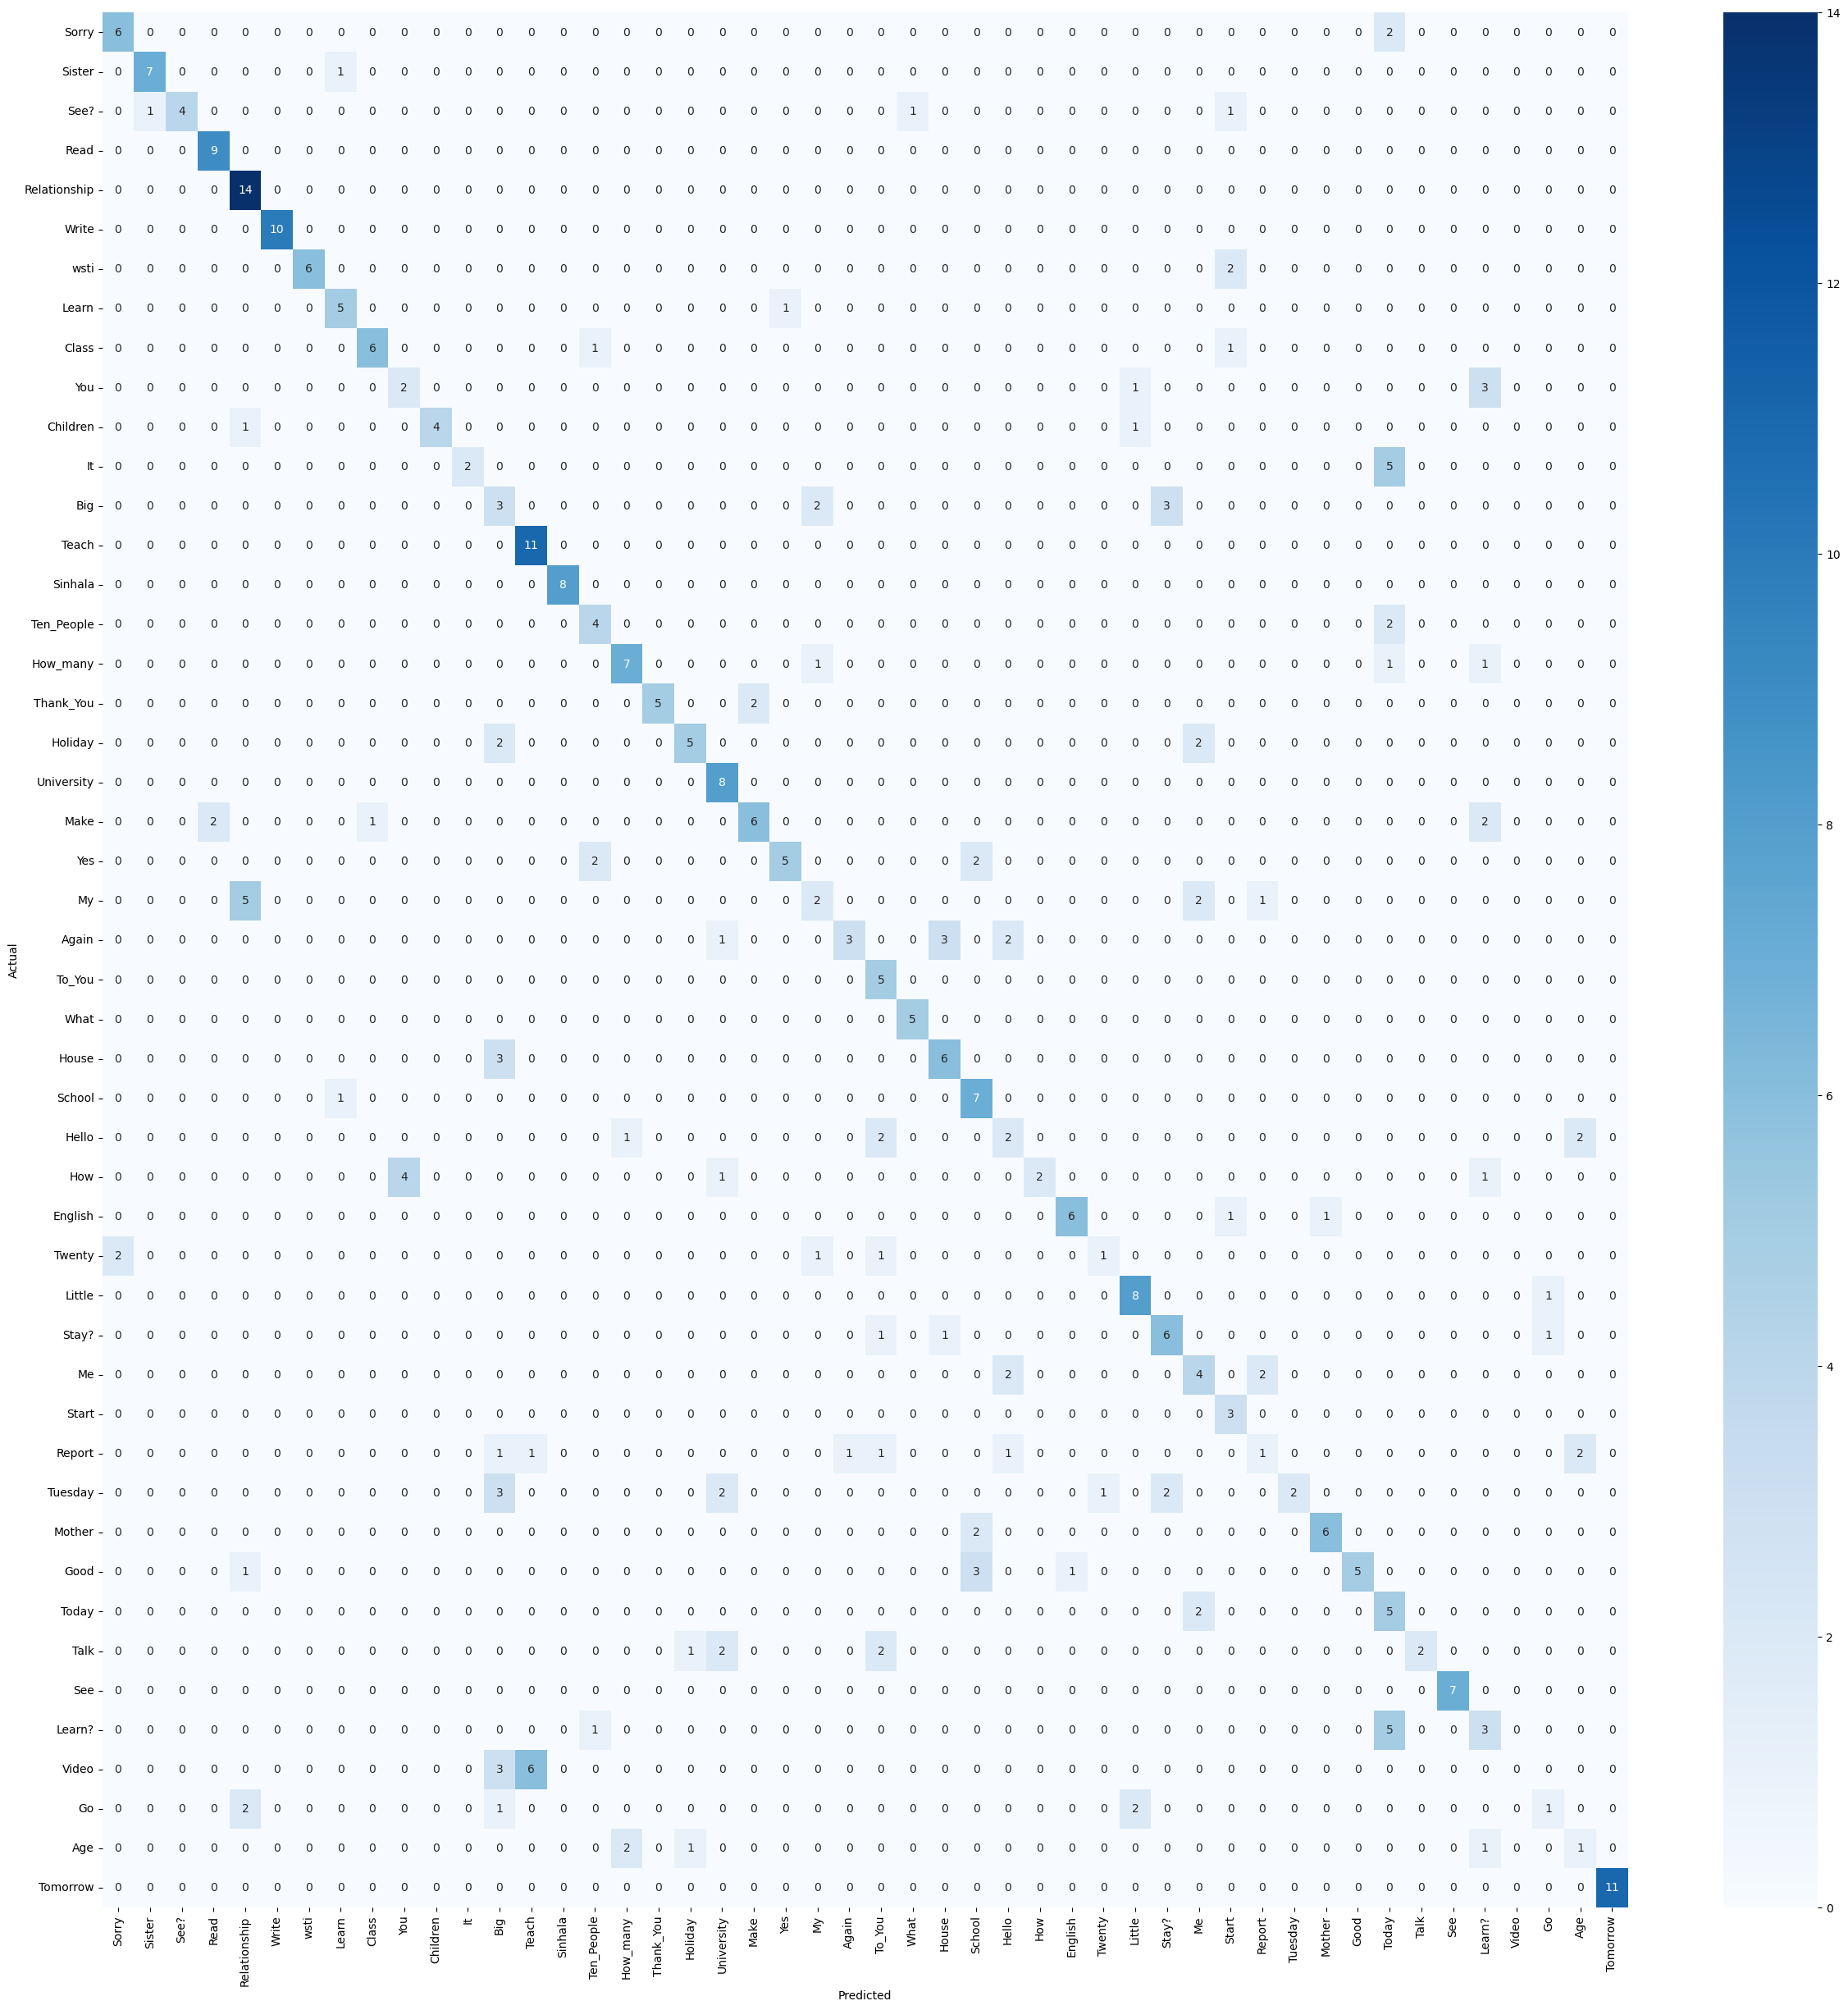

In [190]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test.argmax(axis=1), y_pred_classes)
plt.figure(figsize=(30, 30))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=set(top_classes), yticklabels=set(top_classes))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

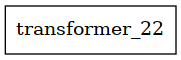

In [191]:
# plot model architecture
plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

In [192]:
exp_number = 16
description = """
64 class SSL dataset, each class having average 4.3 training samples and 8 test samples. model is completely trained on this dataset and model uses same parameters
as model_8 book's one (which uses pre-trained model) 

F1 Score: 0.5607267848442126
Precision: 0.6148751832962359
Recall: 0.582995951417004
Accuracy: 0.582995951417004

F1 Score: 0.5607267848442126
Precision: 0.6148751832962359
Recall: 0.582995951417004
Accuracy: 0.582995951417004

F1 Score: 0.570057665075184
Precision: 0.6372664363302014
Recall: 0.5789473684210527
Accuracy: 0.5789473684210527
"""
result_dir = '../Results/exp_'

# create folder to store results and store results if folder is already there, show error
if not os.path.exists(result_dir + str(exp_number)):
    os.makedirs(result_dir + str(exp_number))

    with open(result_dir + str(exp_number) + '/description.txt', 'w') as f:
        f.write(description)

    # also save plots
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.savefig(result_dir + str(exp_number) + '/accuracy.png')

    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    cm = confusion_matrix(y_test.argmax(axis=1), y_pred_classes)
    plt.figure(figsize=(30, 30))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=set(top_classes), yticklabels=set(top_classes))
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(result_dir + str(exp_number) + '/confusion_matrix.png')


else:
    print("Folder already exists")


Folder already exists
